Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.



🚀 Running architecture: small_128
Eval num_timesteps=20000, episode_reward=-101.19 +/- 0.50
Episode length: 89.80 +/- 4.79
New best mean reward!
Eval num_timesteps=40000, episode_reward=-88.76 +/- 26.43
Episode length: 465.00 +/- 767.81
New best mean reward!
Eval num_timesteps=60000, episode_reward=-45.38 +/- 1.82
Episode length: 2000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=80000, episode_reward=-50.00 +/- 1.04
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=100000, episode_reward=-46.63 +/- 7.30
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=120000, episode_reward=-57.33 +/- 5.43
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=140000, episode_reward=-46.60 +/- 4.36
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=160000, episode_reward=-45.97 +/- 7.41
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=180000, episode_reward=-45.29 +/- 11.23
Episode length: 2000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=200000, episode_reward=-69.92 +/- 7.56
Ep

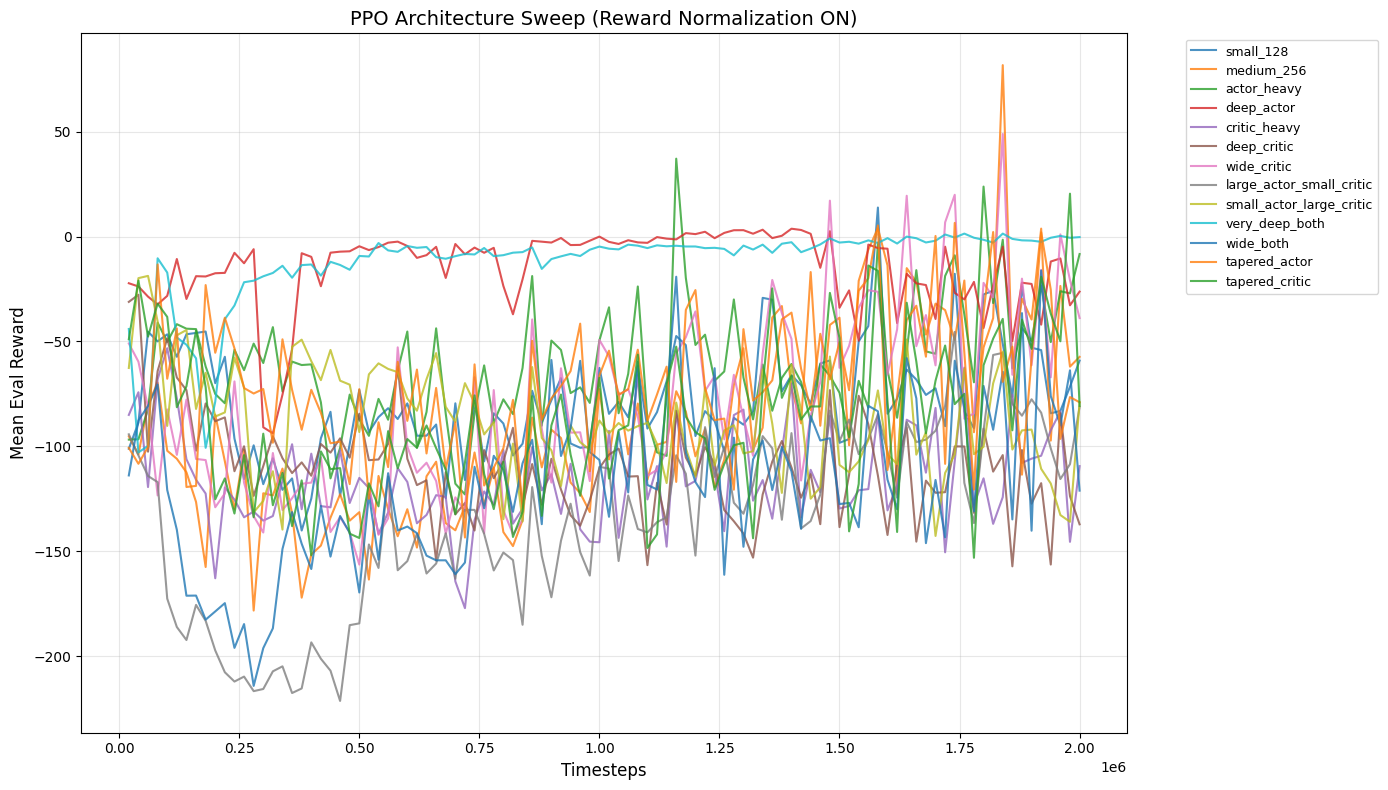

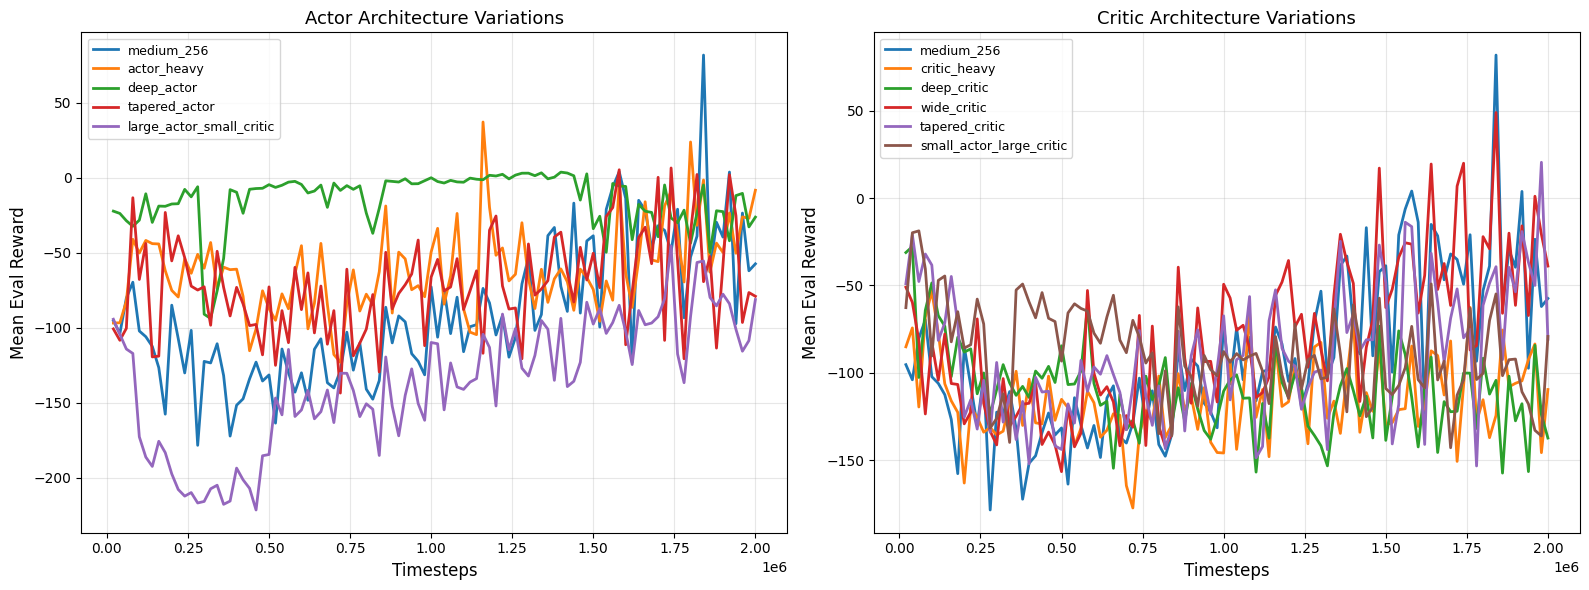


📈 Top 5 Architectures by Final Reward:
  Architecture  Final Reward  Max Reward  Mean Reward
very_deep_both     -0.285991    1.387761   -12.444468
   actor_heavy     -8.355659   37.106638   -61.175792
    deep_actor    -26.273002    3.714170   -14.981732
   wide_critic    -38.887417   48.859494   -79.571303
    medium_256    -57.390052   81.700706   -90.357173


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback

# ===============================
# GLOBAL CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
BASE_LOG_DIR = "./arch_sweep/"
TOTAL_TIMESTEPS = 2_000_000
N_ENVS = 8
SEED = 42

os.makedirs(BASE_LOG_DIR, exist_ok=True)

# ===============================
# LEARNING RATE SCHEDULE
# ===============================
def linear_schedule(initial_lr: float, min_lr: float = 5e-5):
    def func(progress_remaining: float):
        return max(progress_remaining * initial_lr, min_lr)
    return func

# ===============================
# ARCHITECTURE ABLATIONS
# ===============================
ARCHITECTURES = {
    # Original architectures
    "small_128": dict(
        pi=[128, 128],
        vf=[128, 128],
    ),
    "medium_256": dict(
        pi=[256, 256],
        vf=[256, 256],
    ),
    "actor_heavy": dict(
        pi=[256, 256, 128],
        vf=[256, 256],
    ),
    "deep_actor": dict(
        pi=[128, 128, 128, 128],
        vf=[256, 256],
    ),
    
    # New: Critic-heavy architectures
    "critic_heavy": dict(
        pi=[256, 256],
        vf=[256, 256, 256],
    ),
    "deep_critic": dict(
        pi=[256, 256],
        vf=[128, 128, 128, 128],
    ),
    "wide_critic": dict(
        pi=[256, 256],
        vf=[512, 512],
    ),
    
    # New: Asymmetric architectures
    "large_actor_small_critic": dict(
        pi=[512, 512],
        vf=[128, 128],
    ),
    "small_actor_large_critic": dict(
        pi=[128, 128],
        vf=[512, 512],
    ),
    
    # New: Very deep networks
    "very_deep_both": dict(
        pi=[128, 128, 128, 128, 128],
        vf=[128, 128, 128, 128, 128],
    ),
    
    # New: Wide networks
    "wide_both": dict(
        pi=[512, 512],
        vf=[512, 512],
    ),
    
    # New: Tapered architectures
    "tapered_actor": dict(
        pi=[512, 256, 128],
        vf=[256, 256],
    ),
    "tapered_critic": dict(
        pi=[256, 256],
        vf=[512, 256, 128],
    ),
}

# ===============================
# TRAINING LOOP
# ===============================
results_index = []

for name, arch in ARCHITECTURES.items():
    print(f"\n🚀 Running architecture: {name}")

    run_dir = os.path.join(BASE_LOG_DIR, name)
    os.makedirs(run_dir, exist_ok=True)

    # ---- Training env ----
    env = make_vec_env(
        ENV_ID,
        n_envs=N_ENVS,
        seed=SEED,
    )
    env = VecNormalize(
        env,
        norm_obs=True,
        norm_reward=True,
        gamma=0.99,
        clip_obs=10.0,
    )

    # ---- Eval env ----
    eval_env = make_vec_env(
        ENV_ID,
        n_envs=1,
        seed=SEED + 100,
    )
    eval_env = VecNormalize(
        eval_env,
        norm_obs=True,
        norm_reward=False,
        training=False,
    )

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=os.path.join(run_dir, "best_model"),
        log_path=os.path.join(run_dir, "eval"),
        eval_freq=max(20_000 // N_ENVS, 1),
        deterministic=True,
        n_eval_episodes=5,  # Fixed: Added explicit n_eval_episodes
    )

    # ---- Policy kwargs ----
    policy_kwargs = dict(
        activation_fn=nn.Tanh,
        net_arch=dict(pi=arch["pi"], vf=arch["vf"]),  # Fixed: Wrapped in dict
        log_std_init=-1.0,
        ortho_init=False,
    )

    # ---- PPO model ----
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=linear_schedule(2.5e-4),
        n_steps=2048,
        batch_size=1024,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.25,
        ent_coef=0.005,
        vf_coef=0.5,
        max_grad_norm=0.5,
        use_sde=True,
        sde_sample_freq=4,
        seed=SEED,
        verbose=0,
        policy_kwargs=policy_kwargs,
    )

    model.learn(TOTAL_TIMESTEPS, callback=eval_callback)

    # ---- Save artifacts ----
    model.save(os.path.join(run_dir, "final_model"))
    env.save(os.path.join(run_dir, "vec_normalize.pkl"))

    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(
            {
                "architecture": arch,
                "reward_norm": True,
            },
            f,
            indent=2,
        )

    results_index.append(
        {
            "run": name,
            "pi_arch": str(arch["pi"]),  # Fixed: Convert to string for CSV
            "vf_arch": str(arch["vf"]),
            "pi_params": sum(arch["pi"]),  # Added: Approximate param count
            "vf_params": sum(arch["vf"]),
        }
    )

    # Clean up to free memory
    env.close()
    eval_env.close()
    del model

# ---- Save index ----
pd.DataFrame(results_index).to_csv(
    os.path.join(BASE_LOG_DIR, "architecture_index.csv"),
    index=False,
)

print("\n✅ Architecture sweep complete.")

# ===============================
# ANALYSIS + PLOTTING
# ===============================
print("\n📊 Plotting results...")

def load_eval(run_name):
    """Load evaluation results for a given run."""
    path = os.path.join(BASE_LOG_DIR, run_name, "eval", "evaluations.npz")
    try:
        data = np.load(path)
        return data["timesteps"], data["results"].mean(axis=1)
    except FileNotFoundError:
        print(f"⚠️  Warning: Could not find eval data for {run_name}")
        return None, None

# Plot 1: All architectures
plt.figure(figsize=(14, 8))
for run_name in ARCHITECTURES.keys():
    steps, rewards = load_eval(run_name)
    if steps is not None:
        plt.plot(steps, rewards, label=run_name, alpha=0.8)

plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean Eval Reward", fontsize=12)
plt.title("PPO Architecture Sweep (Reward Normalization ON)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_LOG_DIR, "all_architectures.png"), dpi=150)
plt.show()

# Plot 2: Compare actor vs critic variations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actor-focused variations
actor_variants = ["medium_256", "actor_heavy", "deep_actor", "tapered_actor", 
                  "large_actor_small_critic"]
for run_name in actor_variants:
    if run_name in ARCHITECTURES:
        steps, rewards = load_eval(run_name)
        if steps is not None:
            axes[0].plot(steps, rewards, label=run_name, linewidth=2)

axes[0].set_xlabel("Timesteps", fontsize=12)
axes[0].set_ylabel("Mean Eval Reward", fontsize=12)
axes[0].set_title("Actor Architecture Variations", fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Critic-focused variations
critic_variants = ["medium_256", "critic_heavy", "deep_critic", "wide_critic",
                   "tapered_critic", "small_actor_large_critic"]
for run_name in critic_variants:
    if run_name in ARCHITECTURES:
        steps, rewards = load_eval(run_name)
        if steps is not None:
            axes[1].plot(steps, rewards, label=run_name, linewidth=2)

axes[1].set_xlabel("Timesteps", fontsize=12)
axes[1].set_ylabel("Mean Eval Reward", fontsize=12)
axes[1].set_title("Critic Architecture Variations", fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_LOG_DIR, "actor_vs_critic.png"), dpi=150)
plt.show()

# Create summary statistics
summary_data = []
for run_name in ARCHITECTURES.keys():
    steps, rewards = load_eval(run_name)
    if steps is not None and len(rewards) > 0:
        summary_data.append({
            "Architecture": run_name,
            "Final Reward": rewards[-1],
            "Max Reward": rewards.max(),
            "Mean Reward": rewards.mean(),
        })

summary_df = pd.DataFrame(summary_data).sort_values("Final Reward", ascending=False)
summary_df.to_csv(os.path.join(BASE_LOG_DIR, "summary_stats.csv"), index=False)
print("\n📈 Top 5 Architectures by Final Reward:")
print(summary_df.head().to_string(index=False))

In [2]:
import os
import numpy as np
import gymnasium as gym
import imageio
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
BASE_LOG_DIR = "./arch_sweep/"
N_EPISODES = 3  # Generate GIF from N episodes
FPS = 30  # Frames per second for the GIF

# ===============================
# ARCHITECTURE NAMES
# ===============================
ARCHITECTURES = [
    "small_128",
    "medium_256",
    "actor_heavy",
    "deep_actor",
    "critic_heavy",
    "deep_critic",
    "wide_critic",
    "large_actor_small_critic",
    "small_actor_large_critic",
    "very_deep_both",
    "wide_both",
    "tapered_actor",
    "tapered_critic",
]

# ===============================
# GIF GENERATION FUNCTION
# ===============================
def generate_gif_for_model(run_name, model_path, vec_normalize_path, save_dir, n_episodes=3, fps=30):
    """
    Load a trained model and generate a GIF of its performance.
    
    Args:
        run_name: Name of the architecture run
        model_path: Path to the saved model
        vec_normalize_path: Path to the VecNormalize stats
        save_dir: Directory to save the GIF
        n_episodes: Number of episodes to record
        fps: Frames per second for the GIF
    """
    print(f"  📹 Generating GIF for {run_name}...")
    
    # Create environment
    def make_env():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        return env
    
    env = DummyVecEnv([make_env])
    
    # Load VecNormalize stats
    try:
        env = VecNormalize.load(vec_normalize_path, env)
        env.training = False
        env.norm_reward = False
    except FileNotFoundError:
        print(f"  ⚠️  Warning: VecNormalize stats not found for {run_name}, using unnormalized env")
    
    # Load model
    try:
        model = PPO.load(model_path, env=env)
    except FileNotFoundError:
        print(f"  ❌ Error: Model not found at {model_path}")
        env.close()
        return
    
    # Record episodes
    frames = []
    episode_rewards = []
    
    for episode in range(n_episodes):
        obs = env.reset()
        done = False
        episode_reward = 0
        episode_frames = []
        
        while not done:
            # Render frame
            frame = env.render()
            if isinstance(frame, list):
                frame = frame[0]
            episode_frames.append(frame)
            
            # Take action
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            episode_reward += reward[0]
            
            # Check if episode is done
            if done[0]:
                done = True
        
        frames.extend(episode_frames)
        episode_rewards.append(episode_reward)
        print(f"    Episode {episode + 1}/{n_episodes}: Reward = {episode_reward:.2f}")
    
    # Save GIF
    gif_path = os.path.join(save_dir, f"{run_name}_performance.gif")
    imageio.mimsave(gif_path, frames, fps=fps)
    
    # Save episode statistics
    stats_path = os.path.join(save_dir, f"{run_name}_gif_stats.txt")
    with open(stats_path, "w") as f:
        f.write(f"Architecture: {run_name}\n")
        f.write(f"Episodes recorded: {n_episodes}\n")
        f.write(f"Episode rewards: {episode_rewards}\n")
        f.write(f"Mean reward: {np.mean(episode_rewards):.2f}\n")
        f.write(f"Std reward: {np.std(episode_rewards):.2f}\n")
        f.write(f"Min reward: {np.min(episode_rewards):.2f}\n")
        f.write(f"Max reward: {np.max(episode_rewards):.2f}\n")
    
    print(f"  ✅ GIF saved to {gif_path}")
    print(f"  📊 Mean reward: {np.mean(episode_rewards):.2f} ± {np.std(episode_rewards):.2f}")
    
    # Clean up
    env.close()
    del model

# ===============================
# MAIN LOOP
# ===============================
print("🎬 Starting GIF generation for all models...\n")

for arch_name in ARCHITECTURES:
    run_dir = os.path.join(BASE_LOG_DIR, arch_name)
    
    # Check if directory exists
    if not os.path.exists(run_dir):
        print(f"⚠️  Skipping {arch_name}: directory not found")
        continue
    
    # Try best model first, fall back to final model
    best_model_path = os.path.join(run_dir, "best_model", "best_model.zip")
    final_model_path = os.path.join(run_dir, "final_model.zip")
    
    if os.path.exists(best_model_path):
        model_path = best_model_path
        print(f"🏆 Using best model for {arch_name}")
    elif os.path.exists(final_model_path):
        model_path = final_model_path
        print(f"📦 Using final model for {arch_name}")
    else:
        print(f"❌ No model found for {arch_name}, skipping...")
        continue
    
    vec_normalize_path = os.path.join(run_dir, "vec_normalize.pkl")
    
    try:
        generate_gif_for_model(
            run_name=arch_name,
            model_path=model_path,
            vec_normalize_path=vec_normalize_path,
            save_dir=run_dir,
            n_episodes=N_EPISODES,
            fps=FPS,
        )
    except Exception as e:
        print(f"  ❌ Error generating GIF for {arch_name}: {str(e)}")
    
    print()  # Blank line between models

print("✅ GIF generation complete!")

# ===============================
# CREATE INDEX OF GIFS
# ===============================
print("\n📋 Creating GIF index...\n")

gif_index = []
for arch_name in ARCHITECTURES:
    gif_path = os.path.join(BASE_LOG_DIR, arch_name, f"{arch_name}_performance.gif")
    stats_path = os.path.join(BASE_LOG_DIR, arch_name, f"{arch_name}_gif_stats.txt")
    
    if os.path.exists(gif_path) and os.path.exists(stats_path):
        # Read stats
        with open(stats_path, "r") as f:
            lines = f.readlines()
            mean_reward = float(lines[3].split(": ")[1].strip())
            
        gif_index.append({
            "Architecture": arch_name,
            "GIF Path": gif_path,
            "Mean Reward": mean_reward,
        })

# Sort by mean reward
gif_index_sorted = sorted(gif_index, key=lambda x: x["Mean Reward"], reverse=True)

# Save index
index_path = os.path.join(BASE_LOG_DIR, "gif_index.txt")
with open(index_path, "w") as f:
    f.write("=" * 70 + "\n")
    f.write("GIF Index - Sorted by Performance\n")
    f.write("=" * 70 + "\n\n")
    
    for i, entry in enumerate(gif_index_sorted, 1):
        f.write(f"{i}. {entry['Architecture']}\n")
        f.write(f"   Mean Reward: {entry['Mean Reward']:.2f}\n")
        f.write(f"   GIF: {entry['GIF Path']}\n\n")

print(f"📄 GIF index saved to {index_path}")

# Print top performers
print("\n🏆 Top 5 Performing Architectures (by GIF episodes):")
for i, entry in enumerate(gif_index_sorted[:5], 1):
    print(f"  {i}. {entry['Architecture']}: {entry['Mean Reward']:.2f}")

🎬 Starting GIF generation for all models...

🏆 Using best model for small_128
  📹 Generating GIF for small_128...
    Episode 1/3: Reward = 52.01
    Episode 2/3: Reward = -55.54
    Episode 3/3: Reward = 19.99


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


  ✅ GIF saved to ./arch_sweep/small_128\small_128_performance.gif
  📊 Mean reward: 5.49 ± 45.09

🏆 Using best model for medium_256
  📹 Generating GIF for medium_256...
    Episode 1/3: Reward = 158.70
    Episode 2/3: Reward = 10.54
    Episode 3/3: Reward = 17.90
  ✅ GIF saved to ./arch_sweep/medium_256\medium_256_performance.gif
  📊 Mean reward: 62.38 ± 68.18

🏆 Using best model for actor_heavy
  📹 Generating GIF for actor_heavy...
    Episode 1/3: Reward = -2.94
    Episode 2/3: Reward = -49.09
    Episode 3/3: Reward = -120.09
  ✅ GIF saved to ./arch_sweep/actor_heavy\actor_heavy_performance.gif
  📊 Mean reward: -57.37 ± 48.18

🏆 Using best model for deep_actor
  📹 Generating GIF for deep_actor...
    Episode 1/3: Reward = 1.58
    Episode 2/3: Reward = 6.62
    Episode 3/3: Reward = -16.08
  ✅ GIF saved to ./arch_sweep/deep_actor\deep_actor_performance.gif
  📊 Mean reward: -2.62 ± 9.73

🏆 Using best model for critic_heavy
  📹 Generating GIF for critic_heavy...
    Episode 1/3: Rew

🔄 Continuing training for medium_256
   Additional timesteps: 10,000,000

✅ Loading best model from: arch_sweep/medium_256/continued_training/best_model/best_model.zip
🏗️  Setting up environments with unique seeds...
   Creating 8 environments with seeds: 42 to 49
✅ Loaded VecNormalize statistics from: arch_sweep/medium_256/continued_training/vec_normalize.pkl
🎯 Creating evaluation environments with seeds: 1042 to 1046
🤖 Loading model...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: Can't get attribute 'FloatSchedule' on <module 'stable_baselines3.common.utils' from '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/utils.py'>
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: Can't get attribute 'FloatSchedule' on <module 'stable_baselines3.common.utils' from '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/utils.py'>
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

📊 Model has been trained for 10,840,000 timesteps

🚀 Starting continued training...
   Target total timesteps: 20,840,000
   Training for: 10,000,000 additional timesteps
   Environment diversity: 8 parallel envs with UNIQUE seeds



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/evaluation
.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(


💾 Saving final artifacts...
✅ Model saved to: Hope/final_model
✅ Final timesteps: 20,850,624

📊 Plotting learning curves...


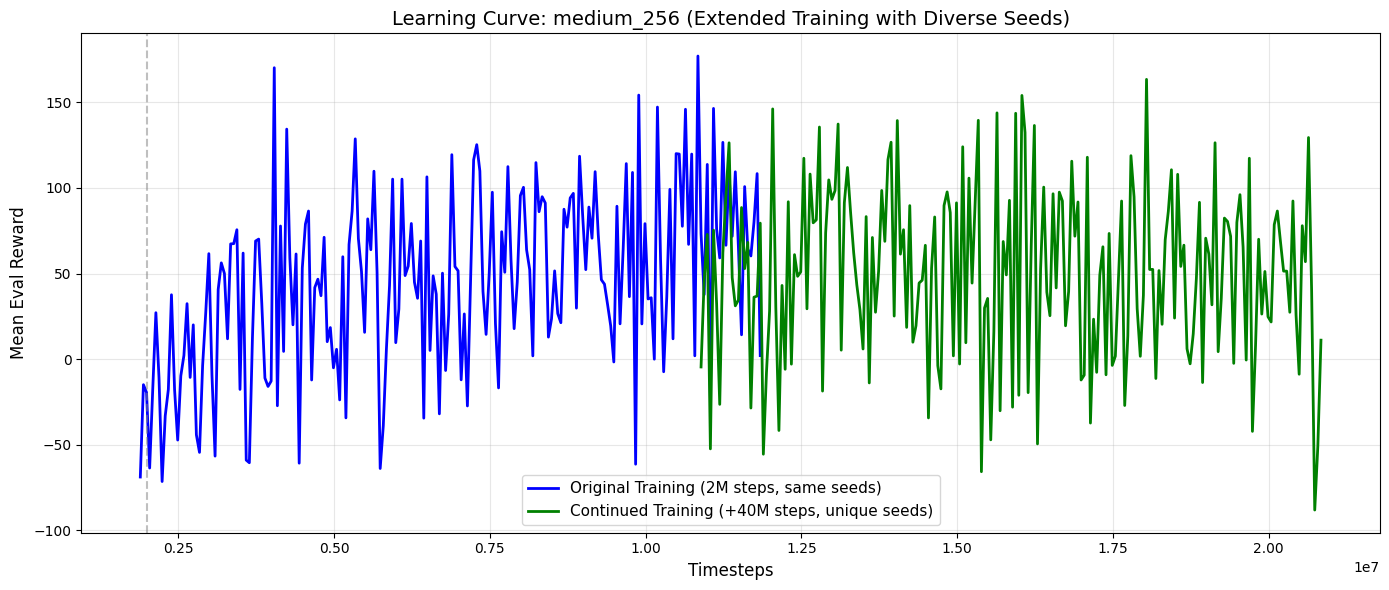

✅ Learning curve saved to: Hope/learning_curve.png

📈 TRAINING SUMMARY

Original Training (2M steps, same seeds):
  Final reward: 2.06
  Best reward:  177.07
  Mean reward:  44.33

Continued Training (+40M steps, unique seeds per env):
  Final reward: 11.07
  Best reward:  163.43
  Mean reward:  49.97

  Peak reward: 163.43 at step 18,040,000
  ⚠️  Degradation: -152.36 (possible overfitting)

  Improvement: +9.01 (+438.5%)

✅ Continued training complete!

💡 Key improvements:
   • Each training env uses unique seed (42-49)
   • Eval envs use different seeds (1042-1046)
   • Better generalization through diverse terrain patterns


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch.nn as nn
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
BASE_LOG_DIR = "./arch_sweep/"
MODEL_NAME = "medium_256"
ADDITIONAL_TIMESTEPS = 10_000_000
N_ENVS = 8
SEED = 42

# Paths
MODEL_DIR = "arch_sweep/medium_256/continued_training"
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model", "best_model.zip")
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_model.zip")
VEC_NORMALIZE_PATH = os.path.join(MODEL_DIR, "vec_normalize.pkl")
CONTINUED_DIR = "Hope"

os.makedirs(CONTINUED_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"⚡ Using device: {DEVICE}")

# ===============================
# LEARNING RATE SCHEDULE
# ===============================
def linear_schedule(initial_lr: float, min_lr: float = 5e-5):
    """Linear learning rate schedule with minimum."""
    def func(progress_remaining: float):
        return max(progress_remaining * initial_lr, min_lr)
    return func

# ===============================
# ENVIRONMENT CREATION WITH UNIQUE SEEDS
# ===============================
def make_env_with_unique_seed(env_id: str, rank: int, seed: int = 0):
    """
    Create a single environment with a unique seed.
    
    Args:
        env_id: Environment ID
        rank: Index of the environment (used to make seed unique)
        seed: Base seed value
    """
    def _init():
        env = gym.make(env_id)
        # Each environment gets a unique seed
        env.reset(seed=seed + rank)
        return env
    return _init

# ===============================
# LOAD MODEL AND CONTINUE TRAINING
# ===============================
print(f"🔄 Continuing training for {MODEL_NAME}")
print(f"   Additional timesteps: {ADDITIONAL_TIMESTEPS:,}\n")

# Check which model to load
if os.path.exists(BEST_MODEL_PATH):
    model_path = BEST_MODEL_PATH
    print(f"✅ Loading best model from: {model_path}")
elif os.path.exists(FINAL_MODEL_PATH):
    model_path = FINAL_MODEL_PATH
    print(f"✅ Loading final model from: {model_path}")
else:
    raise FileNotFoundError(f"❌ No model found for {MODEL_NAME}")

# ---- Training env with UNIQUE SEEDS ----
print("🏗️  Setting up environments with unique seeds...")
print(f"   Creating {N_ENVS} environments with seeds: {SEED} to {SEED + N_ENVS - 1}")

# Create vectorized environment with unique seeds for each parallel env
env = SubprocVecEnv([make_env_with_unique_seed(ENV_ID, i, SEED) for i in range(N_ENVS)])

# Load the VecNormalize wrapper with the saved statistics
if os.path.exists(VEC_NORMALIZE_PATH):
    env = VecNormalize.load(VEC_NORMALIZE_PATH, env)
    env.training = True  # Enable training mode
    env.norm_reward = True
    print(f"✅ Loaded VecNormalize statistics from: {VEC_NORMALIZE_PATH}")
else:
    print("⚠️  Warning: VecNormalize stats not found, creating new wrapper")
    env = VecNormalize(
        env,
        norm_obs=True,
        norm_reward=True,
        gamma=0.99,
        clip_obs=10.0,
    )

# ---- Eval env with DIFFERENT UNIQUE SEEDS ----
print(f"🎯 Creating evaluation environments with seeds: {SEED + 1000} to {SEED + 1004}")

# Create eval envs with different seeds than training (offset by 1000)
eval_env = SubprocVecEnv([make_env_with_unique_seed(ENV_ID, i, SEED + 1000) for i in range(5)])

# Load VecNormalize for eval (use same stats, but don't update them)
if os.path.exists(VEC_NORMALIZE_PATH):
    eval_env = VecNormalize.load(VEC_NORMALIZE_PATH, eval_env)
    eval_env.training = False
    eval_env.norm_reward = False
else:
    eval_env = VecNormalize(
        eval_env,
        norm_obs=True,
        norm_reward=False,
        training=False,
    )

# ---- Callbacks ----
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CONTINUED_DIR, "best_model"),
    log_path=os.path.join(CONTINUED_DIR, "eval"),
    eval_freq=max(50_000 // N_ENVS, 1),
    deterministic=True,
    n_eval_episodes=5,
    verbose=0,
)

# Save checkpoints every 1M timesteps
checkpoint_callback = CheckpointCallback(
    save_freq=max(1_000_000 // N_ENVS, 1),
    save_path=os.path.join(CONTINUED_DIR, "checkpoints"),
    name_prefix="model_checkpoint",
    save_replay_buffer=False,
    save_vecnormalize=True,
)

# ---- Load model ----
print(f"🤖 Loading model...")
model = PPO.load(
    model_path,
    env=env,
    device=DEVICE,
    custom_objects={
        "learning_rate": linear_schedule(2.5e-4),  # Reset learning rate schedule
    }
)

# Get current timesteps (if available)
try:
    initial_timesteps = model.num_timesteps
    print(f"📊 Model has been trained for {initial_timesteps:,} timesteps")
except:
    initial_timesteps = 0
    print(f"⚠️  Could not determine initial timesteps, assuming 0")

print(f"\n🚀 Starting continued training...")
print(f"   Target total timesteps: {initial_timesteps + ADDITIONAL_TIMESTEPS:,}")
print(f"   Training for: {ADDITIONAL_TIMESTEPS:,} additional timesteps")
print(f"   Environment diversity: {N_ENVS} parallel envs with UNIQUE seeds\n")

# ---- Continue training ----
model.learn(
    total_timesteps=ADDITIONAL_TIMESTEPS,
    callback=[eval_callback, checkpoint_callback],
    reset_num_timesteps=False,  # Don't reset the timestep counter
    progress_bar=True,
)

# ---- Save final artifacts ----
print("\n💾 Saving final artifacts...")
final_model_path = os.path.join(CONTINUED_DIR, "final_model")
model.save(final_model_path)
env.save(os.path.join(CONTINUED_DIR, "vec_normalize.pkl"))

# Save training info
training_info = {
    "initial_model": model_path,
    "initial_timesteps": initial_timesteps,
    "additional_timesteps": ADDITIONAL_TIMESTEPS,
    "total_timesteps": model.num_timesteps,
    "architecture": "medium_256",
    "config": {
        "pi": [256, 256],
        "vf": [256, 256],
    },
    "environment_seeds": {
        "training_seeds": list(range(SEED, SEED + N_ENVS)),
        "eval_seeds": list(range(SEED + 1000, SEED + 1005)),
        "n_training_envs": N_ENVS,
        "n_eval_envs": 5,
    }
}

with open(os.path.join(CONTINUED_DIR, "training_info.json"), "w") as f:
    json.dump(training_info, f, indent=2)

print(f"✅ Model saved to: {final_model_path}")
print(f"✅ Final timesteps: {model.num_timesteps:,}")

# Close environments
env.close()
eval_env.close()

# ===============================
# PLOT LEARNING CURVES
# ===============================
print("\n📊 Plotting learning curves...")

def load_eval_data(eval_dir):
    """Load evaluation data from evaluations.npz"""
    eval_file = os.path.join(eval_dir, "evaluations.npz")
    if os.path.exists(eval_file):
        data = np.load(eval_file)
        return data["timesteps"], data["results"].mean(axis=1)
    return None, None

# Load original training data
orig_steps, orig_rewards = load_eval_data(os.path.join(MODEL_DIR, "eval"))

# Load continued training data
cont_steps, cont_rewards = load_eval_data(os.path.join(CONTINUED_DIR, "eval"))

# Create plot
plt.figure(figsize=(14, 6))

if orig_steps is not None and len(orig_steps) > 0:
    plt.plot(orig_steps, orig_rewards, 'b-', label='Original Training (2M steps, same seeds)', linewidth=2)

if cont_steps is not None and len(cont_steps) > 0:
    plt.plot(cont_steps, cont_rewards, 'g-', label='Continued Training (+40M steps, unique seeds)', linewidth=2)

plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean Eval Reward", fontsize=12)
plt.title(f"Learning Curve: {MODEL_NAME} (Extended Training with Diverse Seeds)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=2_000_000, color='gray', linestyle='--', alpha=0.5, label='Training resumed')
plt.tight_layout()

# Save plot
plot_path = os.path.join(CONTINUED_DIR, "learning_curve.png")
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"✅ Learning curve saved to: {plot_path}")

# ===============================
# PRINT SUMMARY STATISTICS
# ===============================
print("\n" + "="*70)
print("📈 TRAINING SUMMARY")
print("="*70)

if orig_rewards is not None and len(orig_rewards) > 0:
    print(f"\nOriginal Training (2M steps, same seeds):")
    print(f"  Final reward: {orig_rewards[-1]:.2f}")
    print(f"  Best reward:  {orig_rewards.max():.2f}")
    print(f"  Mean reward:  {orig_rewards.mean():.2f}")

if cont_rewards is not None and len(cont_rewards) > 0:
    print(f"\nContinued Training (+40M steps, unique seeds per env):")
    print(f"  Final reward: {cont_rewards[-1]:.2f}")
    print(f"  Best reward:  {cont_rewards.max():.2f}")
    print(f"  Mean reward:  {cont_rewards.mean():.2f}")
    
    # Find peak and check for overfitting
    peak_idx = np.argmax(cont_rewards)
    peak_reward = cont_rewards[peak_idx]
    peak_step = cont_steps[peak_idx]
    degradation = cont_rewards[-1] - peak_reward
    
    print(f"\n  Peak reward: {peak_reward:.2f} at step {peak_step:,}")
    if degradation < -5:
        print(f"  ⚠️  Degradation: {degradation:.2f} (possible overfitting)")
    else:
        print(f"  ✅ Degradation: {degradation:.2f} (stable training)")
    
    if orig_rewards is not None and len(orig_rewards) > 0:
        improvement = cont_rewards[-1] - orig_rewards[-1]
        print(f"\n  Improvement: {improvement:+.2f} ({improvement/abs(orig_rewards[-1])*100:+.1f}%)")

print("\n" + "="*70)
print("✅ Continued training complete!")
print("="*70)
print("\n💡 Key improvements:")
print("   • Each training env uses unique seed (42-49)")
print("   • Eval envs use different seeds (1042-1046)")
print("   • Better generalization through diverse terrain patterns")


📊 Plotting learning curves...


<Figure size 1400x600 with 0 Axes>

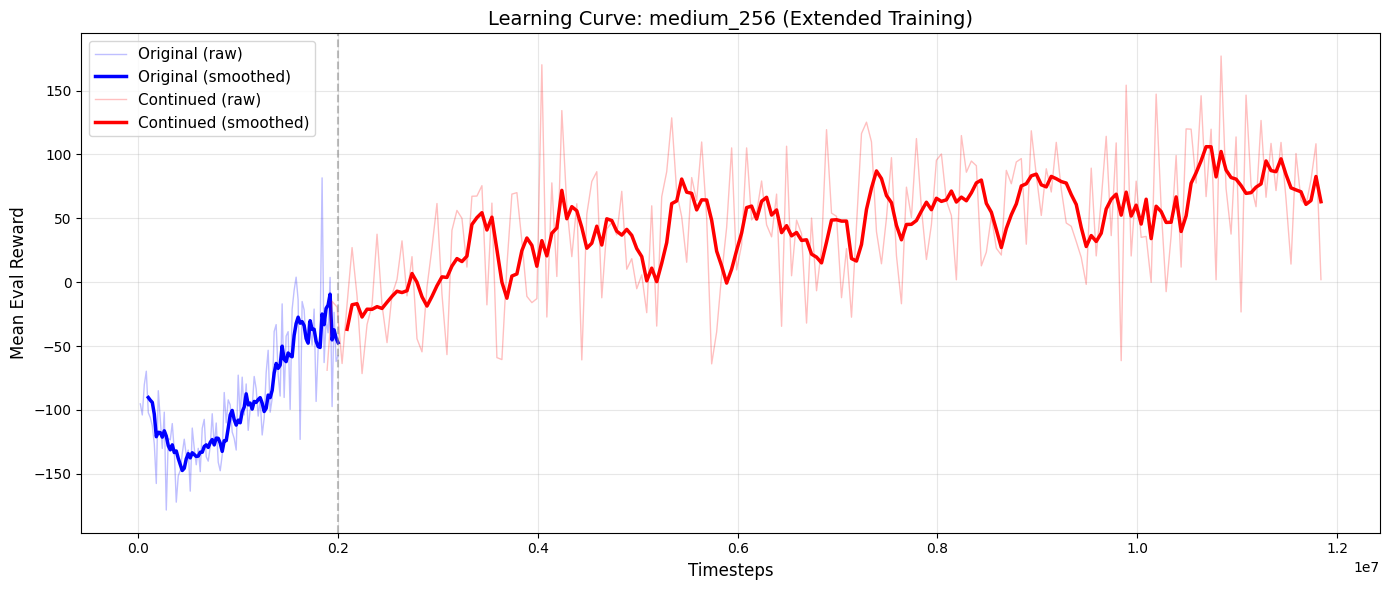

✅ Learning curve saved to: ./arch_sweep/medium_256/continued_training/learning_curve.png

📈 TRAINING SUMMARY

Original Training (2M steps):
  Final reward: -57.39
  Best reward:  81.70
  Mean reward:  -90.36

Continued Training (+10M steps):
  Final reward: 2.06
  Best reward:  177.07
  Mean reward:  44.33

  Improvement: +59.45 (+103.6%)

✅ Continued training complete!


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
BASE_LOG_DIR = "./arch_sweep/"
MODEL_NAME = "medium_256"
ADDITIONAL_TIMESTEPS = 40_000_000
N_ENVS = 8
SEED = 42

# Paths
MODEL_DIR = os.path.join(BASE_LOG_DIR, MODEL_NAME)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model", "best_model.zip")
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_model.zip")
VEC_NORMALIZE_PATH = os.path.join(MODEL_DIR, "vec_normalize.pkl")
CONTINUED_DIR = os.path.join(MODEL_DIR, "continued_training")

# ===============================
# PLOT LEARNING CURVES
# ===============================

def moving_average(x, window):
    if window <= 1:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

print("\n📊 Plotting learning curves...")

def load_eval_data(eval_dir):
    """Load evaluation data from evaluations.npz"""
    eval_file = os.path.join(eval_dir, "evaluations.npz")
    if os.path.exists(eval_file):
        data = np.load(eval_file)
        return data["timesteps"], data["results"].mean(axis=1)
    return None, None

# Load original training data
orig_steps, orig_rewards = load_eval_data(os.path.join(MODEL_DIR, "eval"))

# Load continued training data
cont_steps, cont_rewards = load_eval_data(os.path.join(CONTINUED_DIR, "eval"))

# Create plot
plt.figure(figsize=(14, 6))

SMOOTH_WINDOW = 5

plt.figure(figsize=(14, 6))

# ---------- Original training ----------
if orig_steps is not None and len(orig_steps) > 0:
    # Raw (faded)
    plt.plot(
        orig_steps,
        orig_rewards,
        color='blue',
        alpha=0.25,
        linewidth=1,
        label='Original (raw)'
    )

    # Smoothed
    if len(orig_rewards) > SMOOTH_WINDOW:
        orig_rewards_smooth = moving_average(orig_rewards, SMOOTH_WINDOW)
        orig_steps_smooth = orig_steps[SMOOTH_WINDOW - 1:]

        plt.plot(
            orig_steps_smooth,
            orig_rewards_smooth,
            color='blue',
            linewidth=2.5,
            label='Original (smoothed)'
        )

# ---------- Continued training ----------
if cont_steps is not None and len(cont_steps) > 0:
    # Raw (faded)
    plt.plot(
        cont_steps,
        cont_rewards,
        color='red',
        alpha=0.25,
        linewidth=1,
        label='Continued (raw)'
    )

    # Smoothed
    if len(cont_rewards) > SMOOTH_WINDOW:
        cont_rewards_smooth = moving_average(cont_rewards, SMOOTH_WINDOW)
        cont_steps_smooth = cont_steps[SMOOTH_WINDOW - 1:]

        plt.plot(
            cont_steps_smooth,
            cont_rewards_smooth,
            color='red',
            linewidth=2.5,
            label='Continued (smoothed)'
        )



plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Mean Eval Reward", fontsize=12)
plt.title(f"Learning Curve: {MODEL_NAME} (Extended Training)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=2_000_000, color='gray', linestyle='--', alpha=0.5, label='Training resumed')
plt.tight_layout()

# Save plot
plot_path = os.path.join(CONTINUED_DIR, "learning_curve.png")
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"✅ Learning curve saved to: {plot_path}")

# ===============================
# PRINT SUMMARY STATISTICS
# ===============================
print("\n" + "="*70)
print("📈 TRAINING SUMMARY")
print("="*70)

if orig_rewards is not None and len(orig_rewards) > 0:
    print(f"\nOriginal Training (2M steps):")
    print(f"  Final reward: {orig_rewards[-1]:.2f}")
    print(f"  Best reward:  {orig_rewards.max():.2f}")
    print(f"  Mean reward:  {orig_rewards.mean():.2f}")

if cont_rewards is not None and len(cont_rewards) > 0:
    print(f"\nContinued Training (+10M steps):")
    print(f"  Final reward: {cont_rewards[-1]:.2f}")
    print(f"  Best reward:  {cont_rewards.max():.2f}")
    
    
    print(f"  Mean reward:  {cont_rewards.mean():.2f}")
    
    if orig_rewards is not None and len(orig_rewards) > 0:
        improvement = cont_rewards[-1] - orig_rewards[-1]
        print(f"\n  Improvement: {improvement:+.2f} ({improvement/abs(orig_rewards[-1])*100:+.1f}%)")

print("\n" + "="*70)
print("✅ Continued training complete!")
print("="*70)